# 📊 Application Log Analytics & Anomaly Detection

### Project Overview

Modern distributed systems generate millions of log entries every day. These logs contain valuable information about system health, failures, performance issues, and abnormal behaviors. However, manually analyzing such large volumes of logs is difficult and time-consuming.

This project aims to build an AI-powered Log Analytics and Anomaly Detection system using Deep Learning (LSTM).

# Exploratory Data Analysis (EDA)

As the first step, we performs Exploratory Data Analysis (EDA) on the LogPAI HDFS dataset to understand its structure, characteristics, and anomaly distribution before preprocessing and model development.


### Objectives

- Understand the structure of HDFS log data
- Explore log patterns and distributions
- Analyze Block IDs and event occurrences
- Study anomaly label distribution
- Identify preprocessing requirements
- Generate insights for model development

## Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Ingestion

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/HDFS-Log-Analytics/data/raw"
LOG_FILE = f"{DATA_PATH}/HDFS.log"
LABEL_FILE = f"{DATA_PATH}/anomaly_label.csv"

for file in os.listdir(DATA_PATH):
    print(file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HDFS.log
anomaly_label.csv


#### Dataset Information:

The dataset contains two important files:

* HDFS.log : Contains raw log entries generated by the Hadoop Distributed File System.
* anomaly_label.csv : Contains the ground truth labels indicating whether a Block ID is Normal or Anomalous.

## Anomaly Label Data Exploration

In [ ]:
labels = pd.read_csv(LABEL_FILE)
labels.head(5)

,BlockId,Label
0,blk_-1608999687919862906,Normal
1,blk_7503483334202473044,Normal
2,blk_-3544583377289625738,Anomaly
3,blk_-9073992586687739851,Normal
4,blk_7854771516489510256,Normal


In [ ]:
print("Anomaly Labels Shape:")
print(labels.shape)

print("\nAnomaly Labels Info:")
print(labels.info())

Anomaly Labels Shape:
(575061, 2)

Anomaly Labels Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575061 entries, 0 to 575060
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   BlockId  575061 non-null  object
 1   Label    575061 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB
None


In [ ]:
labels.isnull().sum() # Analyzing Missing value count

,0
BlockId,0
Label,0


Total Blocks      : 575,061
Normal Blocks     : 558,223
Anomalous Blocks  : 16,838


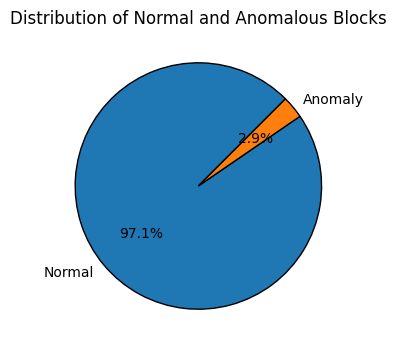

In [ ]:
# Analyzing the proportion of Anomalies in the dataset
label_counts = labels["Label"].value_counts()
print(f"Total Blocks      : {len(labels):,}")
print(f"Normal Blocks     : {label_counts['Normal']:,}")
print(f"Anomalous Blocks  : {label_counts['Anomaly']:,}")

plt.figure(figsize=(4, 4))

plt.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct="%1.1f%%",
    startangle=45,
    wedgeprops={"edgecolor": "black"}
)

plt.title("Distribution of Normal and Anomalous Blocks")
plt.show()



#### Insight:

• The Anomaly Label dataset contains two classes:
  - Normal
  - Anomaly

• Class imbalance present, it should be considered during model development.

## HDFS Log Data Exploration

In [ ]:
# Print first 5 lines of the Log
with open(LOG_FILE, "r") as file:
    for i in range(5):
        print(file.readline().strip())

081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010
081109 203518 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-1608999687919862906
081109 203519 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010
081109 203519 145 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.14.224:42420 dest: /10.250.14.224:50010
081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_-1608999687919862906 terminating


In [ ]:
# Print last 5 lines of the log
from collections import deque

last_lines = deque(maxlen=5)

with open(LOG_FILE, "r") as file:
    for line in file:
        last_lines.append(line.strip())

print("Last 5 Log Entries\n")

for line in last_lines:
    print(line)

Last 5 Log Entries

081111 111557 13 INFO dfs.DataBlockScanner: Verification succeeded for blk_-6171368032583208892
081111 111607 13 INFO dfs.DataBlockScanner: Verification succeeded for blk_6195025276114316035
081111 111613 13 INFO dfs.DataBlockScanner: Verification succeeded for blk_-3339773404714332088
081111 111615 13 INFO dfs.DataBlockScanner: Verification succeeded for blk_1037231945509285002
081111 111628 13 INFO dfs.DataBlockScanner: Verification succeeded for blk_4258862871822415442


In [ ]:
# Top 10 frequent Log entries
messages = Counter()

with open(LOG_FILE, "r") as file:

    for line in file:
        parts = line.split()
        message = " ".join(parts[3:])
        messages[message] += 1

messages.most_common(10)

[('WARN dfs.DataNode$DataXceiver: 10.250.14.224:50010:Got exception while serving blk_-1347702416509823842 to /10.250.14.224:',
  15),
 ('WARN dfs.DataNode$DataXceiver: 10.251.215.192:50010:Got exception while serving blk_8512415457710305414 to /10.251.215.192:',
  13),
 ('WARN dfs.DataNode$DataXceiver: 10.251.30.179:50010:Got exception while serving blk_2356980171746022239 to /10.251.30.179:',
  13),
 ('INFO dfs.FSDataset: Deleting block blk_-1608999687919862906 file /mnt/hadoop/dfs/data/current/blk_-1608999687919862906',
  10),
 ('WARN dfs.DataNode$DataXceiver: 10.251.194.213:50010:Got exception while serving blk_3584987098972940224 to /10.251.194.213:',
  10),
 ('WARN dfs.DataNode$DataXceiver: 10.251.126.255:50010:Got exception while serving blk_548447233881510444 to /10.251.126.255:',
  10),
 ('WARN dfs.DataNode$DataXceiver: 10.251.123.132:50010:Got exception while serving blk_2648141623931869651 to /10.251.123.132:',
  9),
 ('WARN dfs.DataNode$DataXceiver: 10.251.203.149:50010:Got

#### HDFS.log overview:

The HDFS.log file contains raw log entries generated by the Hadoop Distributed File System (HDFS). Each log entry records a system event such as block allocation, block transfer, replication, or storage updates.

Example Log Structure

081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010

Field Breakdown

• Date
• Time
• Process ID
• Log Level
• Component
• Message
• Block ID

In [ ]:
# Analyzing the no. of Log entries
total_lines = 0

with open(LOG_FILE, "r") as file:
    for _ in file:
        total_lines += 1

print(f"Total Log Entries : {total_lines:,}")

Total Log Entries : 11,175,629


In [ ]:
# Calculating average Log length
lengths = []

with open(LOG_FILE, "r") as file:
    for line in file:
        lengths.append(len(line))

print(f"Average Log Length : {np.mean(lengths):.2f} characters")

Average Log Length : 140.20 characters


In [ ]:
# Splitting Log Entry
with open(LOG_FILE, 'r') as file:
    first_log = file.readline().strip()

parts = first_log.split()

for index, value in enumerate(parts):
    print(index, value)

0 081109
1 203518
2 143
3 INFO
4 dfs.DataNode$DataXceiver:
5 Receiving
6 block
7 blk_-1608999687919862906
8 src:
9 /10.250.19.102:54106
10 dest:
11 /10.250.19.102:50010


Counter({'INFO': 10812836, 'WARN': 362793})


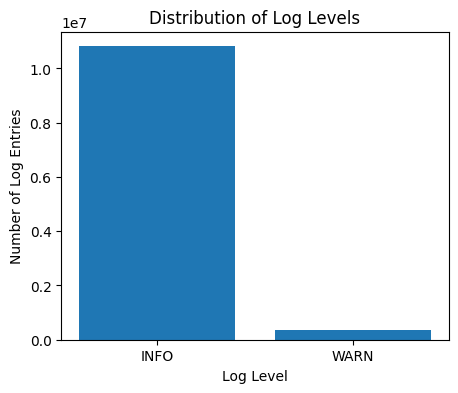

In [ ]:
# Log Level Analysis
from collections import Counter

log_levels = Counter()

with open(LOG_FILE, "r") as file:
    for line in file:
        parts = line.split()
        log_levels[parts[3]] += 1

print(log_levels)

plt.figure(figsize=(5,4))

plt.bar(log_levels.keys(), log_levels.values())

plt.title("Distribution of Log Levels")
plt.xlabel("Log Level")
plt.ylabel("Number of Log Entries")

plt.show()

#### Insight:

- The dataset is dominated by INFO logs.

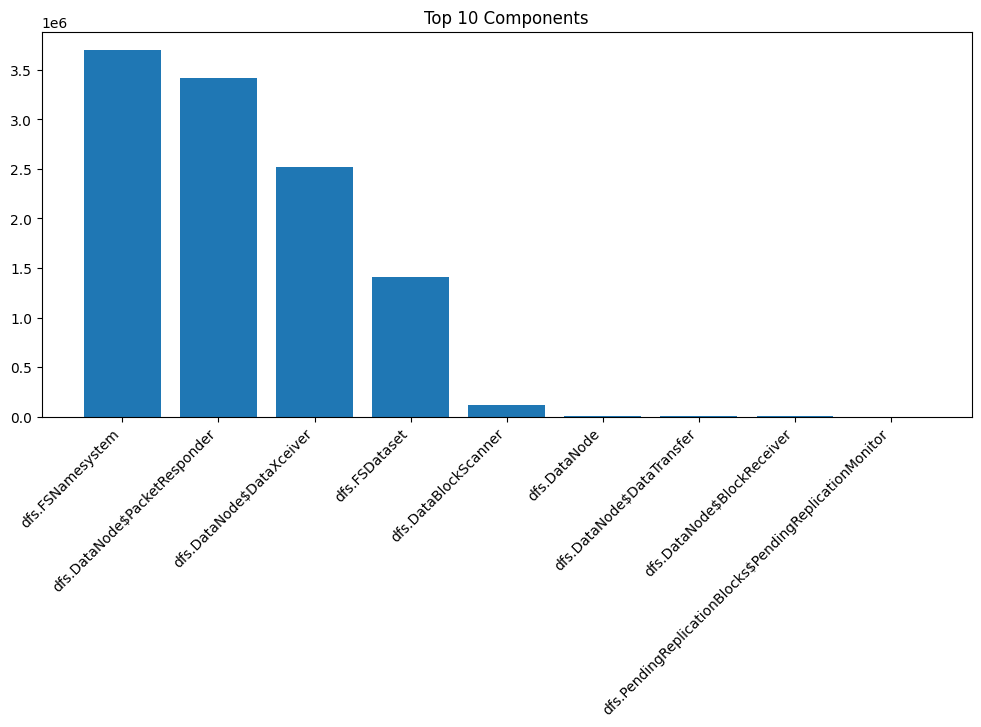

In [ ]:
# Component Analysis
components = Counter()

with open(LOG_FILE, "r") as file:
    for line in file:
        parts = line.split()
        components[parts[4].replace(":", "")] += 1

top10 = components.most_common(10) # No. of occurences of top 10 components.

names = [x[0] for x in top10]
counts = [x[1] for x in top10]

plt.figure(figsize=(12,5))
plt.bar(names, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Components")
plt.show()

#### Insight:

* Components such as **dfs.DataNode$DataXceiver** and **dfs.FSNamesystem** generate the majority of the logs.

In [ ]:
# Block ID Analysis
import re
block_ids = []

pattern = re.compile(r"(blk_-?\d+)") # Extracting Block Id using Regular Expression

with open(LOG_FILE, "r") as file:
    for line in file:
        match = pattern.search(line)
        if match:
            block_ids.append(match.group(1))

print(f"Unique Block IDs : {len(set(block_ids)):,}")
print(f"Total Block References : {len(block_ids):,}")

Unique Block IDs : 575,061
Total Block References : 11,175,629


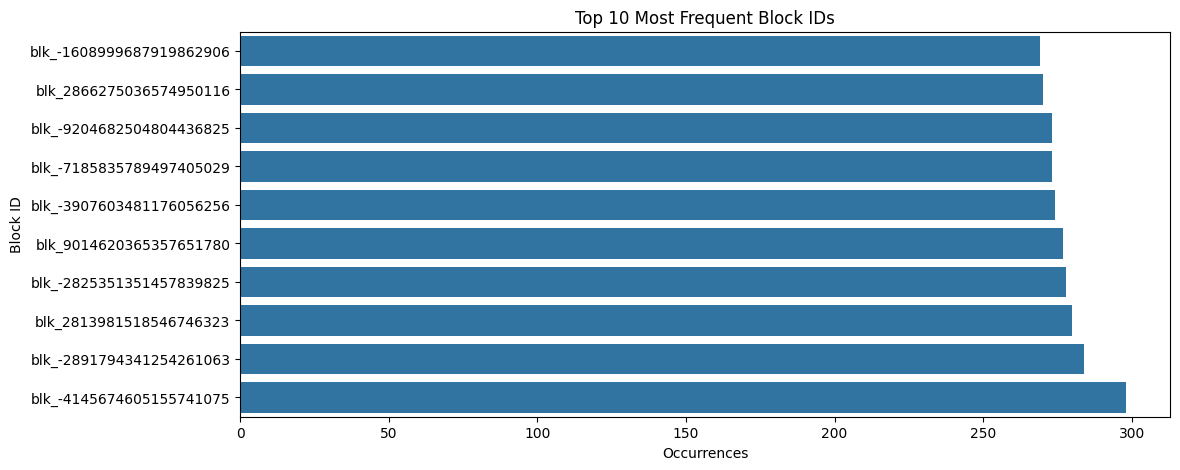

In [ ]:
# Analysing top 10 Frequent Blocks
block_counter = Counter(block_ids)

top_blocks = pd.DataFrame(
    block_counter.most_common(10),
    columns=["Block ID", "Occurrences"]
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=top_blocks,
    x="Occurrences",
    y="Block ID"
)

plt.title("Top 10 Most Frequent Block IDs")
plt.gca().invert_yaxis()
plt.show()

# EDA Summary

### Key Findings

- The HDFS dataset contains millions of log entries generated by multiple Hadoop components.
- Each log entry follows a structured format consisting of timestamp, log level, component, and message.
- Anomaly labels are assigned at the Block ID level.
- The dataset is dominated by INFO-level log entries.
- Multiple log entries correspond to the same Block ID, forming an event sequence.
- Components such as **dfs.DataNode$DataXceiver** and **dfs.FSNamesystem** generate the majority of the logs.


In [ ]:
#EDA Summary
summary = pd.DataFrame({
    "Metric":[
        "Total Log Entries",
        "Unique Block IDs",
        "Unique Components",
        "Unique Log Levels",
        "Normal Blocks",
        "Anomalous Blocks"
    ],
    "Value":[
        total_lines,
        len(set(block_ids)),
        len(components),
        len(log_levels),
        (labels["Label"]=="Normal").sum(),
        (labels["Label"]=="Anomaly").sum()
    ]
})

summary

,Metric,Value
0,Total Log Entries,11175629
1,Unique Block IDs,575061
2,Unique Components,9
3,Unique Log Levels,2
4,Normal Blocks,558223
5,Anomalous Blocks,16838


# Conclusion

The exploratory data analysis provided a comprehensive understanding of the HDFS dataset. The analysis showed that each Block ID is associated with a sequence of log events generated by multiple Hadoop components. Since anomaly labels are assigned at the Block ID level, preprocessing must transform individual log entries into Block ID–based event sequences before training the deep learning model.